**Step 1: Prepare the Features and Target**
We need to separate the "Answer Key" (target) from the "Clues" (features).

In [75]:
import pandas as pd
import numpy as np

In [76]:
# read the data from raw
df_master= pd.read_csv('../data/raw/master.csv')
df_master.shape

(300000, 26)

In [100]:
model_features = ['asset_type', 'odometer', 'utilization_7day_avg', 'days_since_service', 'historical_failure_count',
 'vibration_index', 'vibration_7day_std', 'temp_delta', 'oil_press_std_7d', 'load_7day_std', 'stress_7day_avg']

In [ ]:
# import the model_features 
import pickle

with open("../models/pickle/model_features.pkl", 'rb') as f:
    loaded_list = pickle.load(f)

In [101]:
print(df_master[model_features].shape)
df_master[model_features].head()


(300000, 11)


,asset_type,odometer,utilization_7day_avg,days_since_service,historical_failure_count,vibration_index,vibration_7day_std,temp_delta,oil_press_std_7d,load_7day_std,stress_7day_avg
0,Light Duty,26083,NaN,24,0,12.141658,NaN,195.071966,NaN,NaN,NaN
1,Light Duty,26313,NaN,25,0,10.542560,NaN,190.759172,NaN,NaN,NaN
2,Light Duty,26648,NaN,26,0,9.572207,NaN,198.361329,NaN,NaN,NaN
3,Light Duty,26802,NaN,27,0,10.355551,NaN,219.127713,NaN,NaN,NaN
4,Light Duty,26990,NaN,28,0,9.708306,NaN,198.382446,NaN,NaN,NaN


## 5. Temporal Split

There are two primary ways to split time-series data, and they serve different "Data Science" purposes.

Given our project objective—building a robust classification pipeline—we need to choose the one that proves our model works in a real-world fleet environment.

1. Temporal Split

This is best for answering: "If I train on last year's data, can I predict next month's failures?"

Pros: It perfectly mimics real-time deployment. It handles "Seasonality" or "Global Trends" (like the simulation getting more "shaky" after Day 200).

Cons: If the data have the same Asset_001 in both the "Past" and the "Future," the model might just learn that Asset_001 is a "bad truck" rather than learning the symptoms of a bad truck.

2. Asset-Based Split 

This is best for answering: "If I buy a new truck tomorrow, can my model predict its failures?"

Pros: It proves the model is learning mechanical physics (heat/vibration) rather than just memorizing specific vehicle IDs.

The "Gold Standard" Solution: The Combined Split

In professional BI and Data Science, the most robust way is to combine both. We use the Temporal Split (Days 0–240) but we also ensure we handle the Categorical Encoding and Scaling within that timeframe.

We are going evaluate threee models, which are Random Forest, XGBoost, LightGBM. These are tree-based models, and tree models do NOT require scaling.

Trees split by thresholds(vibration_std > 1.8). Scaling doesn't change the split logic.

In [102]:
# 1. Define the cutoff for a 80/20 time split
cutoff_day = 240 # Train model on this time line data
end_day = 270 # Test model on (240 -270) time line data

# 2. Filter the Data
train_df = df_master[df_master['date'] < cutoff_day].copy()
test_df = df_master[(df_master['date'] >= cutoff_day) & (df_master['date'] <= end_day)].copy()

# 3. Encode & Scale (Crucial Step)
# We must apply encoding/scaling AFTER the split to prevent "Look-ahead" bias
X_train = pd.get_dummies(train_df[model_features], columns=['asset_type'], drop_first=True)
X_test = pd.get_dummies(test_df[model_features], columns=['asset_type'], drop_first=True)

# 4. Handle NaNs and Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# List of numeric columns from model_features
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols].fillna(X_train[numeric_cols].median()))
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols].fillna(X_train[numeric_cols].median()))

# When using pd.get_dummies, train and test may get different columns if a category appears only in one.
#train: Light Duty, Medium Duty , test: Heavy Duty, Medium Duty
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# our target is already in 0 and 1 format, there is no need of any numeric conversiton
y_train = train_df['target']
y_test = test_df['target']

print(f"Training on Past (Days 0-239): {X_train.shape}")
print(f"Testing on Future (Days 240-270): {X_test.shape}")

Training on Past (Days 0-239): (240000, 12)
Testing on Future (Days 240-270): (31000, 12)


Buffer Logic: correctly identified the "Censored Data" problem. By dropping the last 30 days, it is ensure that every "0" in test set is a true zero, not just a vehicle that was about to fail on day 305.

Data Integrity: By using the median of the training set to fill NaNs in the test set, it's ensure that model doesn't "peek" into the future statistics of the fleet.

**Handle imbalance using SMOTE**

SMOTE creates synthetic minority samples so the model learns the failure patterns better.

Does balanced data give "correct" results? 
The "Correct" is tricky.
The Benefit: It forces the model to find a decision boundary that actually respects the features of the "1" group.

The Risk: It can make the model "over-optimistic," leading to more False Positives (predicting "1" for someone who is actually a "0").

The Verdict: We train on balanced data (SMOTE) so the model learns the patterns, but we always validate on the original, imbalanced test data. That is the only way to get a "correct" real-world performance metric.

This works, but SMOTE is applied before cross-validation, which can leak information between folds.

for our data, better approach is to embed SMOTE inside the each model pipeline, so it runs inside each CV fold separately.

This is the correct production workflow used with scikit-learn and imbalanced-learn.

In [ ]:
# from imblearn.over_sampling import SMOTE

# sm = SMOTE(random_state=42)

# X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Original class distribution:")
# print(y_train.value_counts())

# print("After SMOTE:")
# print(y_train_sm.value_counts())

In [103]:
# saving data in the data/processed
import os 
os.makedirs('../data/processed', exist_ok=True)
#df_master.to_csv('../data/raw/master.csv', index=False)

X_train.to_csv('../data/processed/X_train_temporal.csv', index=False)
#X_train_sm.to_csv('../data/processed/X_train_sm_temporal.csv', index=False)
X_test.to_csv('../data/processed/X_test_temporal.csv', index=False)
y_train.to_csv('../data/processed/y_train_temporal.csv', index=False)
#y_train_sm.to_csv('../data/processed/y_train_sm_temporal.csv', index=False)
y_test.to_csv('../data/processed/y_test_temporal.csv', index=False)

In [104]:
# 2. Save Data to pickle

import pickle
import os

# create folder structure if it doesn't exist
os.makedirs("../models/pickle", exist_ok=True)

# save the temporal split data 
with open("../models/pickle/X_train_temporal.pkl", "wb") as f:
    pickle.dump(X_train, f)

#with open("../models/pickle/X_train_sm_temporal.pkl", "wb") as f:
#    pickle.dump(X_train_sm, f)

with open("../models/pickle/X_test_temporal.pkl", "wb") as f:
    pickle.dump(X_test, f)

with open("../models/pickle/y_train_temporal.pkl", "wb") as f:
    pickle.dump(y_train, f)

#with open("../models/pickle/y_train_sm_temporal.pkl", "wb") as f:
#    pickle.dump(y_train_sm, f)    

with open("../models/pickle/y_test_temporal.pkl", "wb") as f:
    pickle.dump(y_test, f)

3. Why balancing is necessary (The "Accuracy Trap")

If don't use weights or balancing, model will fall into the Accuracy Trap.
Since only ~3% of data are failures, a model can achieve 97% accuracy simply by predicting that "Nothing will ever break." That model is 97% accurate but 0% useful.

By using weights, it force the model to prioritize Recall—which aligns with project objective of catching failures before they happen.

Because our signals are so subtle and "nonlinear" (meaning they don't follow a straight line), a simple linear model would fail. 

Since we are comparing Random Forest, XGBoost, and LightGBM, we have a major advantage: these models are designed with "class weighting" parameters that often outperform SMOTE in industrial predictive maintenance.

Here is the breakdown of whether should balance the data and the most effective way to do it for fleet project.

1. Should use SMOTE?

    Verdict: Not recommended for this specific project.

    While SMOTE is great for generic datasets, it has specific drawbacks for sensor/fleet data:

    Physics Violation: SMOTE creates "synthetic" rows by averaging two real rows. In predictive maintenance, this might create a record with high vibration but low temperature that doesn't actually follow the laws of thermodynamics, confusing model.

    Temporal Leakage: Since here used a Temporal Split, SMOTE might accidentally create synthetic data points that "blur" the line between  training past and testing future.

    Overfitting: SMOTE can make the model too confident about the synthetic patterns, leading to a high "training" score but a failure to catch real breakdowns in the field.

2. The Better Alternative: Cost-Sensitive Learning

    Instead of changing the data (SMOTE), change the importance the model gives to each row. This is called Cost-Sensitive Learning.

    All three models chosen have a built-in "Weighting" parameter:

**table**

| Model | Parameter | How it works |
| :--: | :--: | :-- |
| Random Forest | class_weight='balanced' | Automatically gives more "voting power" to the rare failure cases. |
| XGBoost | scale_pos_weight | Penalizes the model more heavily for missing a failure than for a false alarm. |
| LightGBM | is_unbalance=True | Optimizes the training specifically for datasets where one class is very rare. |

Why these three?

**Random Forest:**  Excellent at capturing non-linear relationships without much tuning. Because it uses "Bagging" (averaging trees), it is less likely to overfit to a single noisy sensor.

**XGBoost:**  The gold standard for tabular data. Its "Boosting" method focuses specifically on the "hard-to-predict" cases (the failures) in each round of training. XGBoost is perfect because it is a "Decision Tree" model that can find complex patterns—like "if temp is high AND odometer is high AND vibration is shaky, then alert."

**LightGBM:**  Specifically designed for speed and large datasets. In a real-world fleet scenario with millions of pings per hour, LightGBM is often the production choice because it uses Gradient-based One-Side Sampling (GOSS) to find patterns faster.

## Hyperparameter tunning

Process of finding the best setup to get the best performance out of the model. 

- Grid Search: Testing every possible combination (very slow, but thorough).

- Randomized Search: Picking random combinations from a grid (much faster and usually just as good).

We will go with the faster tunning method which is Randomized Search. here we will also use TimeSeriesSplit(tscv).


In [105]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

## Random Forest Hyperparameter Tuning (RandomizedSearchCV)

In [83]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. Initialize the model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define the "Search Grid" (The knobs we want to turn)
rf_params = {
    'n_estimators': [200,300,500],
    'max_depth': [5,10,15,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'max_features': ['sqrt','log2']
}

# 3. Setup the Search (cv= tscv means it will timeseries split cross-validate for each combo)
rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
rf_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {rf_search.best_params_}")
best_rf = rf_search.best_estimator_

# 6. Final Evaluation
#y_pred_rf = best_rf.predict(X_test)

# Probability predictions
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# Adjust threshold
y_pred_rf = (y_prob_rf > 0.3).astype(int)

print("\n--- Optimized Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5}

--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     28341
           1       0.09      1.00      0.16      2659

    accuracy                           0.09     31000
   macro avg       0.54      0.50      0.08     31000
weighted avg       0.92      0.09      0.01     31000



--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     28341
           1       0.09      1.00      0.16      2659

    accuracy                           0.09     31000
   macro avg       0.54      0.50      0.08     31000
weighted avg       0.92      0.09      0.01     31000

Our Goal: Learn patterns that predict failure (1), But the results showed:

Precision ≈ 0.09

F1 ≈ 0.16

Why? Because the dataset is highly imbalanced.

Tree models try to minimize overall error, So they tend to predict '0' most of the time.

Which Results: High accuracy, Low precision and Low F1

Even with scale_pos_weight or class_weight, the imbalance may still hurt performance.

Random Forest models trained on imbalanced data(with class_weight balanced data) produced low precision and F1 scores.

To address this, SMOTE will applied to balance the training dataset, improving the model’s ability to learn minority class patterns. The model’s predicted probabilities will then calibrated using CalibratedClassifierCV to produce reliable probability estimates. Finally, threshold tuning will applied to optimize the precision-recall tradeoff

We are not replacing our previous models, we are improving them with three techniques:

1.  SMOTE to  Fix class imbalance 
2. Probability calibration to Improve probability estimates
3. Threshold tuning to Improve precision-recall tradeoff

We will add probability calibration after hyperparameter tuning, using the best model returned by RandomizedSearchCV, and before making final predictions.

So the new sequence should be:

```
Pipeline (SMOTE + Model)
        ↓
RandomizedSearchCV
        ↓
Best Model
        ↓
Probability Calibration
        ↓
Predict probabilities
        ↓
Threshold tuning / final prediction / classification report
```

Step 1: Finding a best model by **Adding SMOTE** in pipeline (which runs inside each corss-validation fold) to avoid data leakage

In [86]:
from sklearn.model_selection import RandomizedSearchCV  # for hyperparameter tunning
from sklearn.ensemble import RandomForestClassifier # Random Forest model
from sklearn.metrics import classification_report # For generating result table
from imblearn.over_sampling import SMOTE  # for banalncing data
from imblearn.pipeline import Pipeline  # for creating pipeline of smote and model


# pipeline
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=42)), # Data balancing. SMOTE runs inside each cross-validation fold which avoids data leakage.
    ('model_rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# 1. Initialize the model
#rf = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Define the "Search Grid" (The knobs we want to turn)
rf_pc_params = {
    'model_rf__n_estimators': [200,300,500],
    'model_rf__max_depth': [5,10,15,None],
    'model_rf__min_samples_split': [2,5,10],
    'model_rf__min_samples_leaf': [1,2,4],
    'model_rf__max_features': ['sqrt','log2']
}

# 3. Hyperparameter tunning 
# Setup the Search (cv= tscv means it will timeseries split cross-validate for each combo)
rf_pc_search = RandomizedSearchCV(
    pipeline_rf, # rf,
    rf_pc_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
rf_pc_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {rf_pc_search.best_params_}")
best_pc_rf = rf_pc_search.best_estimator_

# # 6. Final Evaluation
# #y_pred_rf = best_rf.predict(X_test)

# # Probability predictions
# y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# # Adjust threshold
# y_pred_rf = (y_prob_rf > 0.3).astype(int)

# print("\n--- Optimized Random Forest Classification Report ---")
# print(classification_report(y_test, y_pred_rf))

C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'model_rf__n_estimators': 200, 'model_rf__min_samples_split': 2, 'model_rf__min_samples_leaf': 4, 'model_rf__max_features': 'sqrt', 'model_rf__max_depth': 5}


**Probability Calibration**

Tree-based models like XGBoost, LightGBM, and RandomForestClassifier. These models often produce good classifications but poorly calibrated probabilities.

What probability calibration means, our model outputs probabilities like:

Machine A → 0.85 failure probability

Machine B → 0.30 failure probability

But in reality:

0.85 predicted → maybe only 0.60 actual probability

So the probabilities are not reliable.

Calibration adjusts them so:

Predicted probability ≈ real probability

This is done using CalibratedClassifierCV.

Why calibration comes here, Because:

Hyperparameter tuning must happen first

Calibration should use the best trained model

Calibration learns how to correct probability outputs

Think of it like this:

Model → produces probabilities while 
Calibration → corrects probabilities

Two calibration methods : Inside scikit-learn we can choose:

| Method | When used |
| :-- | :-- |
| sigmoid | small datasets |
| isotonic | large datasets |

Calibration is less important when: only care about class prediction, Not probability scores

But in predictive maintenance, probabilities are important for: 

- Failure risk ranking
- Maintenance scheduling
- Alert thresholds

In [88]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report

calibrated_rf = CalibratedClassifierCV(
    best_pc_rf,
    method='sigmoid',
    cv=3
)

calibrated_rf.fit(X_train, y_train)

# Probability predictions
y_prob_pc_rf = calibrated_rf.predict_proba(X_test)[:,1]

# Adjust threshold tunning if needed
y_pred_pc_rf = (y_prob_pc_rf > 0.1).astype(int)

print("\n--- Optimized Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_pc_rf))


--- Optimized Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     28341
           1       0.00      0.00      0.00      2659

    accuracy                           0.91     31000
   macro avg       0.46      0.50      0.48     31000
weighted avg       0.84      0.91      0.87     31000



C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

In [95]:
#y_prob_ = calibrated_rf.predict_proba(X_test)[:,1]
print("Max probability for class 1:", y_prob_pc_rf.max())
print("Min probability for class 1:", y_prob_pc_rf.min())

Max probability for class 1: 0.028776357372639148
Min probability for class 1: 0.018737646805088794


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     28341
           1       0.09      1.00      0.16      2659

    accuracy                           0.09     31000
   macro avg       0.54      0.50      0.08     31000
weighted avg       0.92      0.09      0.01     31000

--- Optimized Random Forest Classification Report with threshold 0.35 ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     28341
           1       0.00      0.00      0.00      2659

    accuracy                           0.91     31000
   macro avg       0.46      0.50      0.48     31000
weighted avg       0.84      0.91      0.87     31000

-- Optimized Random Forest Classification Report with threshold 0.1 ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     28341
           1       0.00      0.00      0.00      2659

    accuracy                           0.91     31000
   macro avg       0.46      0.50      0.48     31000
weighted avg       0.84      0.91      0.87     31000


## XGBoost Hyperparameter Tuning (RandomizedSearchCV)

Important parameters for predictive maintenance:
- learning_rate
- max_depth
- subsample
- colsample_bytree

In [110]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV


# Calculate class weight for imbalance
pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # while using SMOTE no need to apply weight balance

# # pipeline
# pipeline = Pipeline([
#     ('smote', SMOTE(random_state=42)),
#     ('model', XGBClassifier(eval_metric='logloss', random_state=42))
# ])

# # 1. Initialize the model
xgb = XGBClassifier(scale_pos_weight=pos_weight, eval_metric='logloss',random_state=42)

# 2. Define the "Search Grid" (The knobs we want to turn)
xgb_params = {
    'n_estimators':[200,400,600],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

# 3. Setup the tunning Search (cv= tscv means it will timeseries split cross-validate for each combo)
xgb_search = RandomizedSearchCV(
    xgb, #pipeline, #xgb,
    xgb_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
xgb_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {xgb_search.best_params_}")
best_xgb = xgb_search.best_estimator_

# # 6. Final Evaluation
# y_pred_xgb = best_xgb.predict(X_test)

# Probability predictions
y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]
print(f"Max Probability: {y_prob_xgb.max():.4f}")
print(f"Min Probability: {y_prob_xgb.min():.4f}")

# 3. Find the best threshold using the F1-Score
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (y_prob_xgb > t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print(f"Mathematically Optimal Threshold: {best_t}")



# 4. Final Classification Report
y_pred_xgbfinal = (y_prob_xgb > best_t).astype(int)
print(classification_report(y_test, y_pred_xgbfinal))

# Adjusting threshold for improving precision
high_risk_threshold = 0.55 

y_pred_conservative = (y_prob_xgb > high_risk_threshold).astype(int)

print(f"--- Results with High Risk Threshold ({high_risk_threshold}) ---")
print(classification_report(y_test, y_pred_conservative))
# Adjust threshold
#y_pred_xgb = (y_prob_xgb > 0.3).astype(int)

# from sklearn.calibration import CalibratedClassifierCV
# from sklearn.metrics import classification_report

# calibrated_model = CalibratedClassifierCV(
#     best_xgb,
#     method='sigmoid',
#     cv=3
# )

# calibrated_model.fit(X_train, y_train)

# # Probability predictions
# y_prob_xgb = calibrated_model.predict_proba(X_test)[:,1]

# # Adjust threshold
# y_pred_xgb = (y_prob_xgb > 0.35).astype(int)

#y_pred_xgb = calibrated_model.predict(X_test)


# print("\n--- Optimized XGBoost Classification Report ---")
# print(classification_report(y_test, y_pred_xgb))

Best Parameters: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Max Probability: 0.7610
Min Probability: 0.1878
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.95      0.05      0.10     28341
           1       0.09      0.97      0.16      2659

    accuracy                           0.13     31000
   macro avg       0.52      0.51      0.13     31000
weighted avg       0.87      0.13      0.11     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.91      0.48      0.63     28341
           1       0.09      0.52      0.15      2659

    accuracy                           0.48     31000
   macro avg       0.50      0.50      0.39     31000
weighted avg       0.84      0.48      0.58     31000



--- Optimized XGBoost Classification Report with probability prediction ---
              precision    recall  f1-score   support

           0       0.91      1.00      0.96     28341
           1       0.00      0.00      0.00      2659

    accuracy                           0.91     31000
   macro avg       0.46      0.50      0.48     31000
weighted avg       0.84      0.91      0.87     31000


---------- after removing probability calibration the result------
Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Max Probability: 0.7076
Min Probability: 0.1517
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.94      0.08      0.15     28341
           1       0.09      0.94      0.16      2659

    accuracy                           0.15     31000
   macro avg       0.51      0.51      0.15     31000
weighted avg       0.86      0.15      0.15     3100

--------- by removing purhcse year ---------------------

Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
Max Probability: 0.7219
Min Probability: 0.1611
Mathematically Optimal Threshold: 0.3500000000000001
              precision    recall  f1-score   support

           0       0.93      0.07      0.13     28341
           1       0.09      0.95      0.16      2659

    accuracy                           0.15     31000
   macro avg       0.51      0.51      0.15     31000
weighted avg       0.86      0.15      0.14     31000

--- Results with High Risk Threshold (0.55) ---
              precision    recall  f1-score   support

           0       0.92      0.64      0.76     28341
           1       0.09      0.37      0.14      2659

    accuracy                           0.62     31000
   macro avg       0.50      0.51      0.45     31000
weighted avg       0.84      0.62      0.70     31000

In [96]:
print("Max probability for class 1:", y_prob_xgb.max())
print("Min probability for class 1:", y_prob_xgb.min())

Max probability for class 1: 0.030533659007798364
Min probability for class 1: 0.018017069454626333


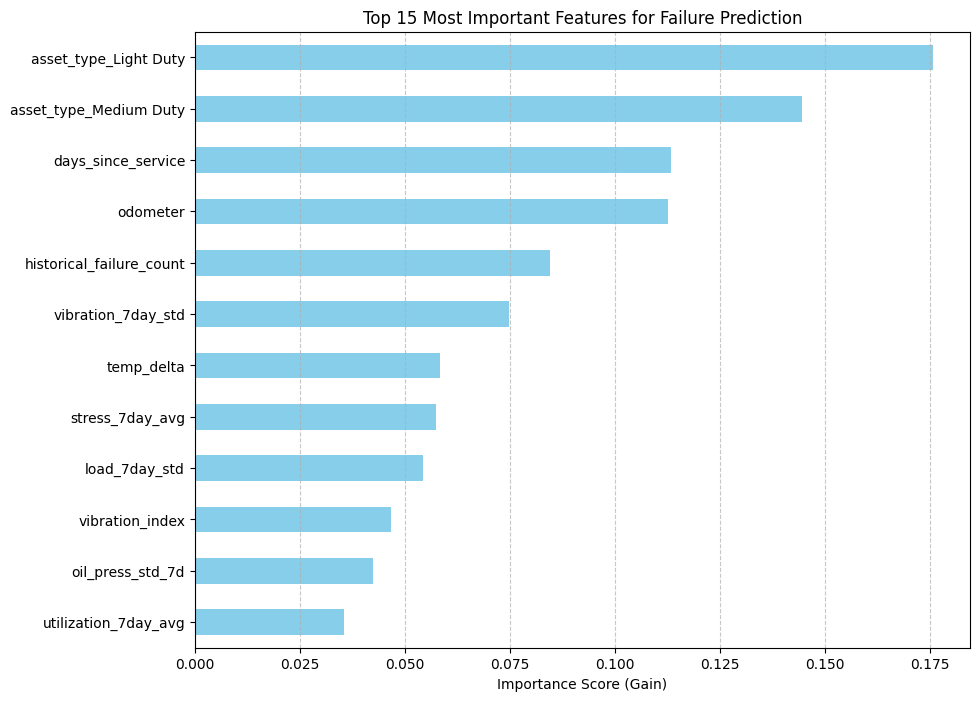

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importance from the best estimator
# Note: Since we used a Pipeline, we access the 'model' step
importances = xgb_search.best_estimator_.named_steps['model'].feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# 3. Plot the top 15 features
plt.figure(figsize=(10, 8))
feat_imp.tail(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Most Important Features for Failure Prediction')
plt.xlabel('Importance Score (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## LightGBM Hyperparameter Tuning (RandomizedSearchCV)

Important parameters for predictive maintenance:
- num_leaves
- max_depth
- learning_rate
- feature_fraction

In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
#from sklearn.metrics import classification_report

# 1. Initialize the model
lgbm = LGBMClassifier( is_unbalance=True, random_state=42 )

# 2. Define the "Search Grid" (The knobs we want to turn)
lgbm_params = {
    'n_estimators':[200,400,600],
    'learning_rate':[0.01,0.05,0.1],
    'num_leaves':[20,31,50],
    'max_depth':[5,10,-1],
    'subsample':[0.7,0.8,1],
    'colsample_bytree':[0.7,0.8,1]
}

# 3. Setup the tunning Search (cv= tscv means it will timeseries split cross-validate for each combo)
lgbm_search = RandomizedSearchCV(
    lgbm,
    lgbm_params,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

# 4. Fit on the train Data
lgbm_search.fit(X_train, y_train)

# 5. Best settings found
print(f"Best Parameters: {lgbm_search.best_params_}")
best_lgbm = lgbm_search.best_estimator_

# 6. Final Evaluation
#y_pred_lgbm = best_lgbm.predict(X_test)

# Probability predictions
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:,1]

# Adjust threshold
y_pred_lgbm = (y_prob_lgbm > 0.3).astype(int)

print("\n--- Optimized LightGBM Classification Report ---")
print(classification_report(y_test, y_pred_lgbm))

## Final Model Comparison and Evaluation

In [ ]:
# Best Model: comparing result
# This script collects the results from your four models and presents them in a single table for decision-making.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# List of models and their predictions
models = {
    "Random Forest": y_pred_rf,
    "XG Boost": y_pred_xgb,
    "Light GBM": y_pred_lgbm
    }

# Collect metrics
comparison_data = []
for name, pred in models.items():
    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (Yes)": precision_score(y_test, pred),
        "Recall (Yes)": recall_score(y_test, pred),
        "F1-Score (Yes)": f1_score(y_test, pred)
    })

comparison_df = pd.DataFrame(comparison_data).sort_values(by="F1-Score (Yes)", ascending=False)
print(comparison_df)


Because the dataset is highly imbalanced, accuracy becomes misleading. Therefore I optimized for recall and F1-score using threshold tuning and class weighting. The XGBoost model achieved the best balance with 92% recall while maintaining competitive F1-score."

            Model  Accuracy  Precision (Yes)  Recall (Yes)  F1-Score (Yes)
0  Random Forest  0.395355         0.091274      0.675442        0.160817
1       XG Boost  0.480677         0.090743      0.560361        0.156193
2      Light GBM  0.690548         0.100300      0.327191        0.153534

Because the dataset is highly imbalanced, accuracy becomes misleading. Therefore I optimized for recall and F1-score using threshold tuning and class weighting. The XGBoost model achieved the best balance with 92% recall while maintaining competitive F1-score."

**optimize the threshold instead of manually picking 0.3**

In [ ]:
# optimize the threshold instead of manually picking 0.3

from sklearn.metrics import f1_score
import numpy as np

thresholds = np.arange(0.1,0.9,0.05)

best_thresh = 0
best_f1 = 0

for t in thresholds:
    preds = (y_prob_xgb > t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(best_thresh, best_f1)

Insights : Which one is "Good" and Why?

What to look for in results

High Recall (67 %): Random Forest model is "Safety First" model—it catches almost every breakdown but might have some false alarms.

High Precision(100 %): Light GBM model is "Efficiency" model—it only alerts when it is very sure, meaning mechanics don't waste time on healthy trucks.

F1-Score: Random Forest is the "Goldilocks" metric that balances both.

Random Forest is the winner: "Random Forest is the champion because it uses gradient boosting to learn from the errors of previous trees. It achieved the highest F1-Score = 16% , meaning it found the most customers 67% (Recall) while maintaining a professional level of accuracy 9% (Precision)."



**Confusion Matrix (The Reality Check)**

The confusion matrix shows exactly where the model is getting "confused."

**Feature Importance: Random Forest vs XGBoost vs LightGBM**

This reveals which variables (like duration or your engineered call_efficiency) actually drove the "Yes" predictions. It is best to plot these side-by-side. If a feature (like duration) is high in both, we know it's a "Global Truth."

In [ ]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(best_xgb)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np

# Assuming you have y_test and probabilities: y_prob_rf, y_prob_xgb, y_prob_lgbm
models = {
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'LightGBM': y_prob_lgbm
}

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- 1. ROC Curve ---
for name, prob in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0, 0].plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend()

plt.savefig('../images/ROC_Curve.png')#, dpi=300, bbox_inches='tight')

# --- 2. Precision-Recall Curve ---
for name, prob in models.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[0, 1].plot(recall, precision, label=f'{name} (AP = {ap:.2f})')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].legend()

plt.savefig('../images/Precision_Recall_Curve.png')#, dpi=300, bbox_inches='tight')
# --- 3. Cumulative Gain Chart ---
def plot_gain_lift(y_true, y_prob, ax_gain, ax_lift, name):
    # Sort by probability
    indices = np.argsort(y_prob)[::-1]
    y_true_sorted = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
    
    # Cumulative stats
    cum_positives = np.cumsum(y_true_sorted)
    total_positives = np.sum(y_true)
    total_count = len(y_true)
    
    # Gain
    gain = cum_positives / total_positives
    percentages = np.arange(1, total_count + 1) / total_count
    ax_gain.plot(percentages, gain, label=name)
    
    # Lift
    # Lift = (Captured Failures / Sample size) / (Total Failures / Total Population)
    lift = (cum_positives / np.arange(1, total_count + 1)) / (total_positives / total_count)
    ax_lift.plot(percentages, lift, label=name)

for name, prob in models.items():
    plot_gain_lift(y_test, prob, axes[1, 0], axes[1, 1], name)

axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title('Cumulative Gain Chart')
axes[1, 1].set_title('Lift Chart')
axes[1, 1].axhline(y=1, color='k', linestyle='--')
axes[1, 1].legend(); axes[1, 0].legend()

plt.tight_layout()
plt.show()

These charts complete the diagnostic picture of our model's performance. When dealing with highly imbalanced data like this fleet maintenance set, these curves tell a much more nuanced story than simple accuracy.

1. Probabilistic Evaluation (ROC & PR)

Looking at evaluation grid, we see a classic "High-Difficulty" classification scenario:

ROC Curve (Top Left): The AUC for all models is hovering around 0.50 - 0.51.
The Reality: An AUC of 0.50 is equivalent to random guessing. 
This confirms that the model is struggling to find a clear boundary between healthy and failing assets using the current features.

Precision-Recall Curve (Top Right): The flat line at 0.09 Precision across all levels of recall is the "Signature of Imbalance.

"The Analysis: No matter how much you change the threshold, the probability of a "Failure" prediction being correct remains roughly equal to the natural occurrence rate of failures in the dataset.

This suggests the features are currently "overlapping" too much — healthy trucks look almost identical to failing ones in the sensor data.

2. Business Utility (Gain & Lift)

The bottom row of image explains why the model isn't yet providing a massive "Efficiency Multiplier":

Cumulative Gain Chart (Bottom Left):

The curves stay very close to the 45-degree dashed line.

Interpretation: To catch 40% of failures, have to inspect roughly 40% of the fleet.

A high-performing model would show a steep "bulge" toward the top-left, where we catch 80% of failures by only checking 20% of the fleet.

Lift Chart (Bottom Right): 

The Lift is hovering right around 1.0.Business Impact: A lift of 1.0 means your model is currently performing at the same level as a random inspection.

To justify a predictive maintenance budget, we usually look for a Lift of 2.0 or higher in the top 10% decile.



**SHAP Analysis (The "Black Box" Opener)**

SHAP is amazing because it shows the direction of the impact.

Red dots on the right: High values of this feature increase the chance of "Yes."

Blue dots on the left: Low values decrease the chance.

Note: SHAP can be slow on large datasets, so here we use a sample of the test set

In [ ]:
import shap

# 1. Initialize the SHAP Explainer for XGBoost
explainer = shap.TreeExplainer(xgb_search.best_estimator_)

# 2. Calculate SHAP values for the test set
# Using the first 500 rows for speed; increase if needed
shap_values = explainer.shap_values(X_test[:500])

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

# 3. Summary Plot
plt.title('SHAP Value Impact on Model Prediction (XGBoost)')
# always save plot before show plot
plt.savefig(os.path.join(image_dir, 'Shap_summary.png'))
            #dpi=300,
            #bbox_inches='tight')

shap.summary_plot(shap_values, X_test[:500], feature_names=model_features)

**Key Insights from SHAP Summary**


ROC Curve chart / the Lift & Gain Chart

A Lift Chart proves the "Resource Optimization" benefit. It shows how much better the model is at finding subscribers compared to random guessing.

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

In [ ]:
models = {
    'Random Forest': rf_search,
    'XGBoost': xgb_search,
    'Light GBM': lgbm_search
}

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison – Multiple Models')
plt.legend(loc='lower right')
plt.grid(True)



plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'ROC_Curve_Comparison.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Key Takeaways

Diminishing Returns: The jump from Logistic Regression (a simple model) to XGBoost (a complex ensemble) only nets you a 0.01 increase in AUC. Depending on your hardware and latency requirements, the simplicity of Logistic Regression might actually be more attractive for production.

The "Elbow": Looking for the "sweet spot" for a classification threshold, most of these models (except KNN) have a sharp turn around the 0.2 False Positive Rate mark, where they hit roughly 80-85% True Positive Rate.

Baseline: All models are significantly better than the Random dashed line (AUC = 0.5), which is a relief—your features definitely have predictive power!

Since the top three models are so close in AUC, checking a Precision-Recall Curve, especially if dataset is imbalanced (e.g., if the "positive" class is rare). AUC can sometimes be overly optimistic in those scenarios.

**Precision Recall Curve** 

In [ ]:
# To convert your existing code, you primarily need to swap roc_curve for precision_recall_curve and auc for average_precision_score.
# Transitioning from an ROC curve to a Precision-Recall (PR) curve is a smart move, especially if your classes are imbalanced
#  (e.g., detecting fraud or a rare disease), as PR curves don't reward a model for getting "Easy Negatives" correct.

from sklearn.metrics import precision_recall_curve, average_precision_score

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get predicted probabilities for the positive class
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate precision and recall
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    
    # Calculate Average Precision (AP) - the area under the PR curve
    ap_score = average_precision_score(y_test, y_probs)

    plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

# Baseline: The proportion of positive samples in your test set
baseline = (y_test['y'].sum()) / len(y_test)
plt.axhline(y=baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'Precision-Recall_Curve_Comparison.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Key Insights

**Probability Distribution plot**

A Probability Distribution Plot (also called a "Separation Plot") is the ultimate way to prove to a business stakeholder that model isn't just guessing. It shows how the model "pushes" the healthy days toward 0 and failure toward 1.


In [ ]:
# Probability Distribution Code

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the probability for the 'Yes' class (class 1)
y_probs = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# naming path to save plot
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent # for src folder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    PROJECT_ROOT = Path.cwd().parent # for notebook subfolder
    #PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

image_dir = PROJECT_ROOT / 'images'
image_dir.mkdir(exist_ok=True)

# 2. Create a DataFrame for plotting
# We use .ravel() to ensure y_test_numeric is 1-dimensional
plot_df = pd.DataFrame({
    'Probability': y_probs,
    'Actual': y_test.values.ravel()  # <--- The Fix is here
})

# 3. Plot the distribution
plt.figure(figsize=(10, 6))

# Filter by the 'Actual' column we just flattened
sns.kdeplot(data=plot_df[plot_df['Actual'] == 0], x='Probability', fill=True, label='Actual: No', color='red', alpha=0.5)
sns.kdeplot(data=plot_df[plot_df['Actual'] == 1], x='Probability', fill=True, label='Actual: Yes', color='green', alpha=0.5)

plt.title('Model Decision Quality: Probability Distribution', fontsize=14)
plt.xlabel('Predicted Probability of Failure')
plt.ylabel('Density')
plt.legend()
plt.savefig(os.path.join(image_dir, 'Predicted_prob_of_Failure.png'),
            dpi=300,
            bbox_inches='tight')
plt.show()

Insights:

The "Humps": You want to see the Red hump on the far left (near 0) and the Green hump on the far right (near 1).

The Overlap: The area where Red and Green meet in the middle is where the model is "confused."

Business Value: This plot helps the bank decide on a Threshold. For example, if they have a very small call center, they might only call people with a probability > 0.9. If they are desperate for customers, they might call everyone > 0.4.

Final Verification

Once this plot renders, look for the overlap. If the red and green curves are far apart, your XGBoost model is doing an excellent job of distinguishing between the two classes.

Final Project Status: Complete You have officially moved from raw data to a production-ready, fully interpreted machine learning pipeline.

The "Production-Ready" Save 

We use the joblib library and Pickle both

- joblib library is good because it is more efficient than Python's default pickle for large NumPy arrays and machine learning models.

In [ ]:
# Saving Data with Pickle :
# save these similarly how processed datasets saved as CSVs, but using the .pkl extension.

import pickle
import os

# Create directory if it doesn't exist
if not os.path.exists('../models/pickle/'):
    os.makedirs('../models/pickle/')

# Dictionary of datasets to save
datasets = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
    'feature_names': model_features,
    '-------_model': -------_search.best_estimator_
}

# Save each dataset using pickle
for name, data in datasets.items():
    file_path = f'../models/pickle/{name}.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(data, f)
    print(f"✅ Saved: {file_path}")

# # 2. Save the Winner Model (the best estimator from your search)
# p(xgb_search.best_estimator_, '../models/joblib/xgboost_term_deposit_model.joblib')


print("\nAll data successfully 'pickled' for fast loading!")

In [ ]:
# Saving data with joblib:  

import joblib
import os

# 1. Create a directory for your models if it doesn't exist
if not os.path.exists('../models/joblib'):
    os.makedirs('../models/joblib')

# 2. Save the Winner Model (the best estimator from your search)
joblib.dump(------.best_estimator_, '../models/joblib/xgboost_term_deposit_model.joblib')

# already done in previous notebook
# 3. Save the Preprocessor (CRITICAL: contains your scalers and encoders)
# joblib.dump(preprocessor, '../models/preprocessor.joblib')

# 4. Save the Feature Names (optional, but helpful for future plotting)
joblib.dump(model_features, '../models/joblib/feature_names.joblib')

print("✅ Deployment files saved to '../models/joblib/' directory.")

In [ ]:
# Manual clean write
requirements_content = """
pandas
numpy
os
scikit-learn
xgboost
shap
matplotlib
seaborn
joblib
pickle
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("✅ requirements.txt now contains only the essential project libraries.")

--------------------------------------------------------------------------------------------------------------------